<a href="https://colab.research.google.com/github/Rogerio-mack/IMT_CD_2026/blob/main/IMT_CD_P2B_2026S1_solucao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<head>
  <meta name="author" content="Rogério de Oliveira">
  <meta institution="author" content="ITM">
</head>

<img src="https://maua.br/images/selo-60-anos-maua.svg" width=300, align="right">
<!-- <h1 align=left><font size = 6, style="color:rgb(200,0,0)"> optional title </font></h1> -->




# **P2 - ECM514 Ciência de Dados**



In [7]:
#@markdown Nome **COMPLETO** e RA

Nome = 'P2 gabarito B' #@param {type:"string"}
RA = '22.01164-0' #@param {type:"string"}
#@markdown

suffix_file = RA.replace('.','')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

path = 'https://github.com/Rogerio-mack/IMT_CD_2026/raw/main/data/'
!wget -q https://github.com/Rogerio-mack/work/raw/refs/heads/main/data/housingb.csv -O housing.csv

Q1, Q2, Q3, Q4, Q5, Q6, Q7 = {},{},{},{},{},{},{}

example_dict = {
    'Q1': Q1,
    'Q2': Q2,
    'Q3': Q3,
    'Q4': Q4,
    'Q5': Q5,
    'Q6': Q6,
    'Q7': Q7
}

#@markdown Execute para prosseguir...

In [8]:
from statsmodels.datasets import co2
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

# **CASO: Titanic Survivals**

Os dados do acidente do Titanic são até hoje uma das maiores fontes de dados para correlacionar fatores de sobrevivência do ser humano a desastres. Faça a análise de alguns desses fatores.






In [9]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Q1. **Verifique se o fato de embarcar sem acompanhante tem influência significativa na sobrevivência dos passageiros.**


In [10]:
df.survived = df.survived.replace({0:'Died',1:'Survived'})

In [11]:
from scipy.stats import chi2_contingency

ct = pd.crosstab(df.survived, df.alone)
# ct = pd.crosstab(df.alive, df.alone)

chi2, p_value, dof, expected =  chi2_contingency(ct)
print(f'Chi-square statistic: {chi2:.3f}')
print(f'p-value: {p_value:.3f}')

print()
if p_value < 0.05:
	print('Rejeitamos a hipótese nula. O fato de embarcar sem acompanhante influenciou significativamente a sobrevivência.')
else:
	print('Não rejeitamos a hipótese nula. O fato de embarcar sem acompanhante não influenciou significativamente a sobrevivência.')

Chi-square statistic: 36.001
p-value: 0.000

Rejeitamos a hipótese nula. O fato de embarcar sem acompanhante influenciou significativamente a sobrevivência.


In [12]:
p_value

np.float64(1.9726543846517183e-09)

In [13]:
ct = pd.crosstab(df.alone,df.alive,normalize='index')
ct

alive,no,yes
alone,,
False,0.494350,0.505650
True,0.696462,0.303538


In [14]:
ct.loc[False,'yes'] / ct.loc[True,'yes']

np.float64(1.6658521368410104)

A análise a seguir, de resíduos, não foi pedida, mas é apresentada aqui como um adicional.

* residual positivo → mais casos observados que o esperado
* residual negativo → menos casos observados que o esperado

In [15]:
residuals = (ct - expected) / np.sqrt(expected)
display(residuals)

alive,no,yes
alone,,
False,-14.735455,-18.162276
True,-11.596958,-14.335780


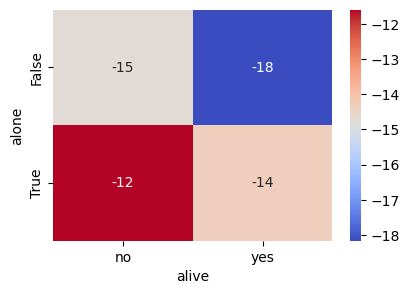

In [16]:
plt.figure(figsize=(4.5,3))

sns.heatmap(residuals, annot=True, cmap='coolwarm')
plt.show()

In [17]:
#@markdown #### Q1A. Qual o teste de hipótese escolhido e o p-value encontrado para esse problema?
#@markdown Teste escolhido:
Q1A1 = 'chi2_contingency' #@param {type:"string"}
#@markdown p-value:
Q1A2 = 0.000 #@param {type:"number"}

Q1['Q1A1. Teste escolhido'] = Q1A1
Q1['Q1A2. p-value'] = Q1A2

In [18]:
#@markdown #### Q1B. O embarque desacompanhado tem influência na sobrevivência dos passageiros? (Sim ou Não)
Q1B1 = 'Sim' #@param {type:"string"}

Q1['Q1B1. O embarque desacompanhado influência na sobrevivência dos passageiros?'] = Q1B1

In [19]:
#@markdown #### Q1C. Se o fato de embarcar desacompanhado tem influência na sobrevivência, quantas vezes a probabilidade de sobrevivência de ter embarcado acompanhado é maior que a de ter embarcado desacompanhado?
#@markdown (*informe 1.00 para todos valores se o fato de embarcar acompanhado não teve influência significativa na sobrevivência*).
#@markdown
#@markdown

#@markdown $P_{A}=P(sobrevivência|acompanhado)$
Q1C1 = 0.505 #@param {type:"number"}
#@markdown $P_{B}=P(sobrevivência|desacompanhado)$
Q1C2 = 0.303 #@param {type:"number"}
#@markdown $P_{A}/P_{B}$
Q1C3 = np.round(Q1C1 / Q1C2,2)

# Create a FloatText widget to display the value
value_widget = widgets.FloatText(
    value=Q1C3,
    description='P_A/P_B',
    disabled=True
)

# Display the widget
display(value_widget)

Q1['Q1C1. P(sobrevivência|acompanhado)'] = Q1C1
Q1['Q1C2. P(sobrevivência|desacompanhado)'] = Q1C2
Q1['Q1C3. P_A/P_B'] = Q1C3



FloatText(value=1.67, description='P_A/P_B', disabled=True)

## Q2. **Passageiros mais jovens estão associados a maiores taxas de sobrevivência?**

Você pode assumir, independentemente de um teste estatístico, as idades atende o pressuposto de normalidade. Ainda assim, pode haver outros pressupostos a verificar.


In [20]:
age_survived = df[df.survived == 'Survived'].age.dropna()
age_died = df[df.survived == 'Died'].age.dropna()

Pelo D’Agostino K² Test as amostras não tem distribuição normal, mas tratando-se de idades, conforme o enunciado, vamos assumir esse pressuposto.

In [21]:
from scipy.stats import normaltest
import numpy as np

stat, p = normaltest(age_survived)
print(p)
stat, p = normaltest(age_died)
print(p)

0.44535080559478313
9.786307175880915e-06


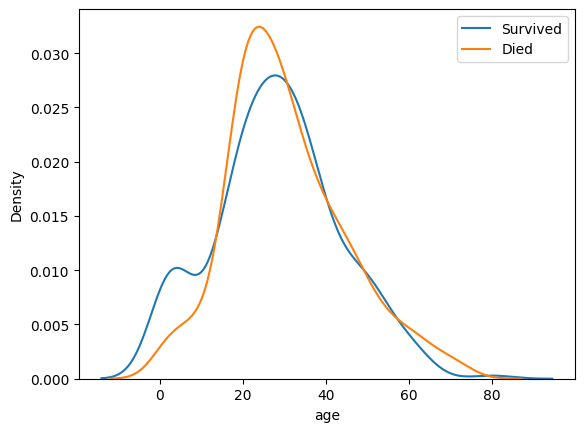

In [22]:
sns.kdeplot(age_survived, label='Survived')
sns.kdeplot(age_died, label='Died')
plt.legend()
plt.show()

Apesar de não haver diferença significativa das variâncias (testes de bartlett e levene abaixo), o usual é o emprego do teste t-Welch. São, entretanto, no exercício, aceitas as duas respostas.

In [23]:
from scipy.stats import bartlett

stat, p = bartlett(age_survived, age_died)

print(f"Levene's test statistic: {stat:.3f}")
print(f"p-value: {p_value:.3f}")

Levene's test statistic: 0.988
p-value: 0.000


In [24]:
from scipy.stats import levene

age_survived = df[df.survived == 'Survived'].age.dropna()
age_died = df[df.survived == 'Died'].age.dropna()

# Perform Levene's test for equality of variances
stat, p_value = levene(age_survived, age_died)

print(f"Levene's test statistic: {stat:.3f}")
print(f"p-value: {p_value:.3f}")

if p_value < 0.05:
    print("Rejeitamos a hipótese nula: as variâncias das idades nos grupos 'Survived' e 'Died' são significativamente diferentes.")
else:
    print("Não rejeitamos a hipótese nula: não há evidência suficiente para afirmar que as variâncias das idades nos grupos 'Survived' e 'Died' são significativamente diferentes.")

Levene's test statistic: 1.195
p-value: 0.275
Não rejeitamos a hipótese nula: não há evidência suficiente para afirmar que as variâncias das idades nos grupos 'Survived' e 'Died' são significativamente diferentes.


In [25]:
from scipy.stats import levene

age_survived = df[df.survived == 'Survived'].age.dropna()
age_died = df[df.survived == 'Died'].age.dropna()

# Perform Levene's test for equality of variances
stat, p_value = levene(age_survived, age_died)

print(f"Levene's test statistic: {stat:.3f}")
print(f"p-value: {p_value:.3f}")

if p_value < 0.05:
    print("Rejeitamos a hipótese nula: as variâncias das idades nos grupos 'Survived' e 'Died' são significativamente diferentes.")
else:
    print("Não rejeitamos a hipótese nula: não há evidência suficiente para afirmar que as variâncias das idades nos grupos 'Survived' e 'Died' são significativamente diferentes.")

Levene's test statistic: 1.195
p-value: 0.275
Não rejeitamos a hipótese nula: não há evidência suficiente para afirmar que as variâncias das idades nos grupos 'Survived' e 'Died' são significativamente diferentes.


### t-Welch

In [26]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(df[df.survived == 'Survived'].age.dropna(), df[df.survived == 'Died'].age.dropna(), equal_var=False, alternative='less')

print("Resultados do Teste t de Student (Alternative: less):")
print(f"Estatística t: {t_stat:.3f}")
print(f"p-valor: {p_value:.3f}")
print()

if p_value < 0.05:
    print("Rejeitamos a hipótese nula. A idade dos sobreviventes é significativamente menor que a dos não sobreviventes.")
else:
    print("Não rejeitamos a hipótese nula. A idade dos sobreviventes não é significativamente menor que a dos não sobreviventes.")

Resultados do Teste t de Student (Alternative: less):
Estatística t: -2.046
p-valor: 0.021

Rejeitamos a hipótese nula. A idade dos sobreviventes é significativamente menor que a dos não sobreviventes.


### t-test

In [27]:
t_stat, p_value = ttest_ind(df[df.survived == 'Survived'].age.dropna(), df[df.survived == 'Died'].age.dropna(), alternative='less')

print("Resultados do Teste t de Student (Alternative: less):")
print(f"Estatística t: {t_stat:.3f}")
print(f"p-valor: {p_value:.3f}")
print()

if p_value < 0.05:
    print("Rejeitamos a hipótese nula. A idade dos sobreviventes é significativamente menor que a dos não sobreviventes.")
else:
    print("Não rejeitamos a hipótese nula. A idade dos sobreviventes não é significativamente menor que a dos não sobreviventes.")

Resultados do Teste t de Student (Alternative: less):
Estatística t: -2.067
p-valor: 0.020

Rejeitamos a hipótese nula. A idade dos sobreviventes é significativamente menor que a dos não sobreviventes.


### dCohen

In [28]:
import numpy as np

A = df[df.survived == 'Survived'].age.dropna()
B = df[df.survived == 'Died'].age.dropna()
mean_diff = np.mean(B) - np.mean(A)

pooled_std = np.sqrt(
    (
        np.std(B, ddof=1)**2 +
        np.std(A, ddof=1)**2
    ) / 2
)

d = mean_diff / pooled_std

print(d)

0.15669189080299376


In [29]:
#@markdown #### Q2A. Qual o teste de hipótese escolhido e o p-value encontrado para esse teste?
#@markdown Teste escolhido e seus parâmetros:
Q2A1 = "ttest_ind(a, b, equal_var=False, alternative='less')" #@param {type:"string"}
#@markdown p-value:
Q2A2 = 0.020 #@param {type:"number"}

Q2['Q2A1. Teste escolhido'] = Q2A1
Q2['Q2A2. p-value'] = Q2A2

In [30]:
#@markdown #### Q2B. Passageiros mais jovens estiveram associados a maiores taxas de sobrevivência? (Sim ou Não)
Q2B1 = 'Sim' #@param {type:"string"}

Q2['Q2B1. Passageiros mais jovens estiveram associados a maiores taxas de sobrevivência?'] = Q2B1

In [31]:
#@markdown #### Q2C. Qual o influência/efeito do teste anterior, isto é, da relação entre ser mais jovens e maiores taxas de sobrevivência? Isso tem uma influência/efeito grande?
#@markdown (*informe 1.00 se não for significativo*).
#@markdown
#@markdown


#@markdown Qual a estatística escolhida para o tamanho da influência/efeito?
Q2C1 = 'dCohen' #@param {type:"string"}
#@markdown Qual o valor encontrado dessa estatística?
Q2C2 = 0.15 #@param {type:"number"}
#@markdown A influência é grande, média ou pequena?
Q2C3 = 'pequena' #@param {type:"string"}

Q2['Q2C1. Estatística escolhida'] = Q2C1
Q2['Q2C2. Valor encontrado'] = Q2C2
Q2['Q2C3. Influência'] = Q2C3


# **CASE: US House Sales**

Na economia encontramos muitos "ciclos" representados por perídos de crescimento, uma queda, e um novo ciclo. Neste CASE você vai selecionar um ciclo de crescimento, fazer e analisar um modelo de previsão ARIMA para este ciclo.



In [32]:
%%script echo off
import pandas_datareader as pdr

reader = pdr.fred.FredReader(["HOUST"], start="1980-01-01", end="2024-12-01")
data = reader.read()
housing = data.HOUST

################################################################################

np.random.seed(42)
housing = housing + np.random.choice([-1, 1], size=len(housing))
housing.index.freq = housing.index.inferred_freq

housing = pd.DataFrame(housing).reset_index()
housing.to_csv('housingb.csv', index=False)
housing = pd.read_csv('housingb.csv')
housing.index = pd.DatetimeIndex(housing.DATE)
housing.drop(columns=['DATE'],inplace=True)
housing = pd.Series(housing.HOUST)
housing.index.freq = housing.index.inferred_freq
display(housing.sum())

################################################################################

off


,DATE,HOUST
0,1980-01-01,1340
1,1980-02-01,1351
2,1980-03-01,1046
3,1980-04-01,1050
4,1980-05-01,926
...,...,...
535,2024-08-01,1395
536,2024-09-01,1358
537,2024-10-01,1369
538,2024-11-01,1299


,HOUST
DATE,
1980-01-01,1340
1980-02-01,1351
1980-03-01,1046
1980-04-01,1050
1980-05-01,926
...,...
2024-08-01,1395
2024-09-01,1358
2024-10-01,1369


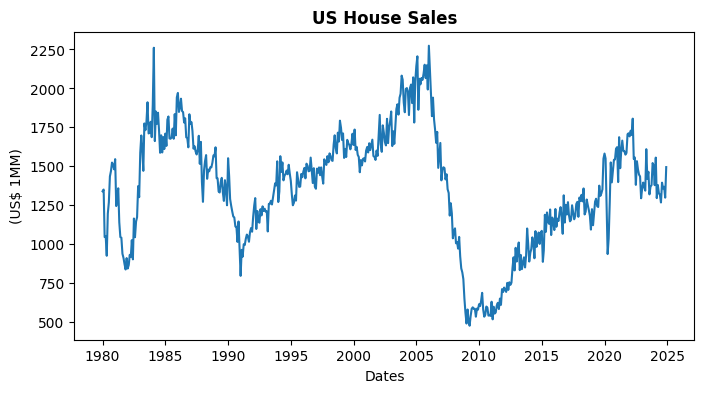

In [33]:
housing = pd.read_csv('housing.csv')
display(housing)

housing.index = pd.DatetimeIndex(housing.DATE)
housing.drop(columns=['DATE'],inplace=True)
housing = pd.Series(housing.HOUST)
housing.index.freq = housing.index.inferred_freq

display(housing)

fig = plt.figure(figsize=(8, 4))
plt.plot(housing)
plt.title('US House Sales',weight='bold')
plt.xlabel('Dates')
plt.ylabel('(US$ 1MM)')
plt.show()


## Q3. Produza um gráfico como abaixo para Série US House Sales

> **Recomendo fazer este exercício ao final.** Ele está aqui por exibir a série e, assim, ajudar o entendimento dos dados. Mas não é necessário para solução dos exercícios seguintes e pode demandar muito tempo.

Crie uma função `plot_interval()` que produza gráficos como abaixo, para delimitar e exibir um "ciclo" do seu início ao fim na fase de crescimento.

```
plot_interval(data_inicio_min, data_fim_min, data_inicio_max, data_fim_max)
```

Nesta função, dado dois intervalos de data, ela localiza o valor mínimo (do primeiro intervalo) e o máximo (do segundo intervalo) delimitando esses valores no gráfico como abaixo.

Produza o gráfico o mais semelhante possível. A proporção entre os dois gráficos é 2:1 (largura). Para reproduzir o subplot e tamanho da figura, você pode empregar:

```
  fig = plt.figure(figsize=(12, 4))

  ax1 = plt.subplot2grid((1, 3), (0, 0), colspan=2) # First subplot takes 2 columns out of 3
  ax2 = plt.subplot2grid((1, 3), (0, 2), colspan=1) # Second subplot takes 1 column out of 3
```



In [34]:
df = housing.copy()

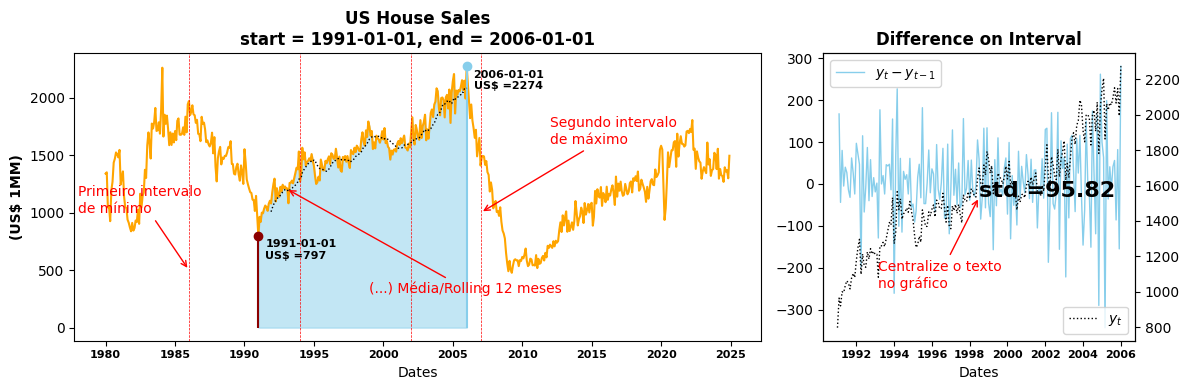

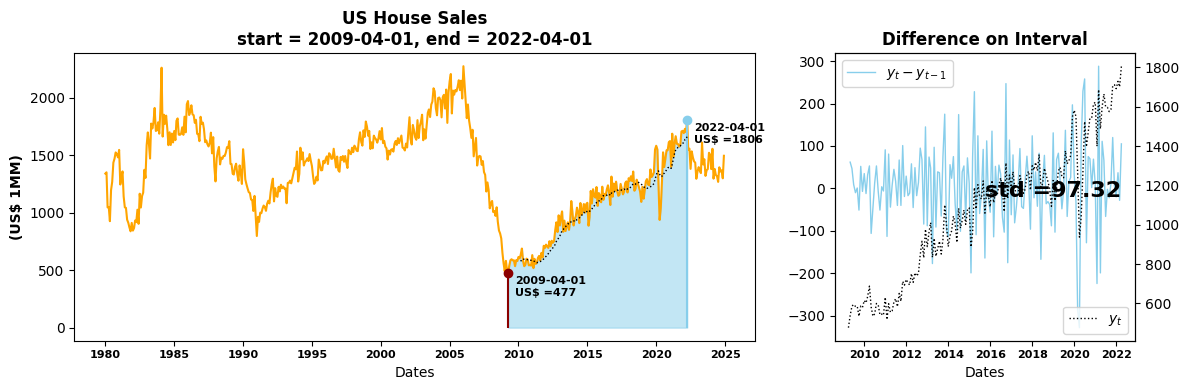

In [35]:
def plot_interval1(data_inicio_min, data_fim_min, data_inicio_max, data_fim_max):
  fig = plt.figure(figsize=(12, 4))

  ax1 = plt.subplot2grid((1, 3), (0, 0), colspan=2) # First subplot takes 2 columns out of 3
  ax2 = plt.subplot2grid((1, 3), (0, 2), colspan=1) # Second subplot takes 1 column out of 3

  a = df[(df.index > data_inicio_min) & (df.index < data_fim_min)].idxmin()
  b = df[(df.index > data_inicio_max) & (df.index < data_fim_max)].idxmax()

  ax1.plot(df, color='orange')
  ax1.set_title(f'US House Sales\nstart = {str(a)[0:10]}, end = {str(b)[0:10]}',weight='bold')
  ax1.set_xlabel('Dates')
  ax1.set_ylabel('(US$ 1MM)',weight='bold')

  ax1.axvline(pd.to_datetime(data_inicio_min), color='red', linestyle='--', lw=0.5)
  ax1.axvline(pd.to_datetime(data_fim_min), color='red', linestyle='--', lw=0.5)
  ax1.axvline(pd.to_datetime(data_inicio_max), color='red', linestyle='--', lw=0.5)
  ax1.axvline(pd.to_datetime(data_fim_max), color='red', linestyle='--', lw=0.5)

  ax1.vlines(a, 0, df.loc[a], color='darkred')
  ax1.vlines(b, 0, df.loc[b], color='skyblue')

  ax1.plot(a, df.loc[a], marker='o', color='darkred')
  ax1.plot(b, df.loc[b], marker='o', color='skyblue')

  ax1.text(a + pd.DateOffset(months=6), df.loc[a] - 200, str(a)[0:10] + '\nUS$ =' + str(df.loc[a]), fontsize=8, weight='bold')
  ax1.text(b + pd.DateOffset(months=6), df.loc[b] - 200, str(b)[0:10] + '\nUS$ =' + str(df.loc[b]), fontsize=8, weight='bold')
  ax1.fill_between(df.index, df, where=(df.index >= a) & (df.index <= b), color='skyblue', alpha=0.5)

  ax1.set_xticks(ax1.get_xticks(), ax1.get_xticklabels(),fontsize=8,weight='bold')

  ax1.plot(df[(df.index >= a) & (df.index <= b)].rolling(12).mean(),color='black',linestyle=':',linewidth=1)

  ax3 = ax2.twinx()

  ax2.plot(df[(df.index >= a) & (df.index <= b)].diff().dropna(), color='skyblue' , label='$y_t - y_{t-1}$',linewidth=1)
  ax2.set_title('Difference on Interval',weight='bold')
  ax2.set_xlabel('Dates')
  ax2.set_xticks(ax2.get_xticks(), ax2.get_xticklabels(),fontsize=8,weight='bold')
  ax2.legend(loc='upper left',fontsize=10)

  xmin, xmax = ax2.get_xlim()
  ymin, ymax = ax2.get_ylim()
  ax2.text(a + (b - a)/2, (ymax + ymin)/2, 'std =' + str(np.round(df[(df.index >= a) & (df.index <= b)].diff().dropna().std(),2)),fontsize=16, weight='bold')

  ax3.plot(df[(df.index >= a) & (df.index <= b)],color='black',linestyle=':',linewidth=1, label='$y_t$')
  ax3.legend(loc='lower right',fontsize=10)

  # você não precisa disso
  xmin, xmax = ax3.get_xlim()
  ymin, ymax = ax3.get_ylim()
  ax3.annotate('Centralize o texto\nno gráfico',
              xy = (pd.to_datetime(str(a)[0:10]) + (pd.to_datetime(str(b)[0:10]) - pd.to_datetime(str(a)[0:10]))/2, (ymax + ymin)/2),
              xytext = (pd.to_datetime(str(a)[0:10]) + (pd.to_datetime(str(b)[0:10]) - pd.to_datetime(str(a)[0:10]))/7, (ymax + ymin)/3),
              arrowprops=dict(arrowstyle="->",color='red'),
              color = 'red')

  ax1.annotate('Primeiro intervalo \nde mínimo',
              xy = (pd.to_datetime(data_inicio_min), 500),
              xytext = (pd.to_datetime('1978-01-01'), 1000),
              arrowprops=dict(arrowstyle="->",color='red'),
              color = 'red')

  ax1.annotate('Segundo intervalo \nde máximo',
              xy = (pd.to_datetime(data_fim_max), 1000),
              xytext = (pd.to_datetime('2012-01-01'), 1600),
              arrowprops=dict(arrowstyle="->",color='red'),
              color = 'red')

  ax1.annotate('(...) Média/Rolling 12 meses',
              xy = (pd.to_datetime('1993-01-01'), df.loc['1993-01-01']),
              xytext = (pd.to_datetime('1999-01-01'), 300),
              arrowprops=dict(arrowstyle="->",color='red'),
              color = 'red')

  plt.tight_layout()
  plt.show()

  return

def plot_interval(data_inicio_min, data_fim_min, data_inicio_max, data_fim_max):
  fig = plt.figure(figsize=(12, 4))

  ax1 = plt.subplot2grid((1, 3), (0, 0), colspan=2) # First subplot takes 2 columns out of 3
  ax2 = plt.subplot2grid((1, 3), (0, 2), colspan=1) # Second subplot takes 1 column out of 3

  a = df[(df.index > data_inicio_min) & (df.index < data_fim_min)].idxmin()
  b = df[(df.index > data_inicio_max) & (df.index < data_fim_max)].idxmax()

  ax1.plot(df, color='orange')
  ax1.set_title(f'US House Sales\nstart = {str(a)[0:10]}, end = {str(b)[0:10]}',weight='bold')
  ax1.set_xlabel('Dates')
  ax1.set_ylabel('(US$ 1MM)',weight='bold')

  ax1.vlines(a, 0, df.loc[a], color='darkred')
  ax1.vlines(b, 0, df.loc[b], color='skyblue')

  ax1.plot(a, df.loc[a], marker='o', color='darkred')
  ax1.plot(b, df.loc[b], marker='o', color='skyblue')

  ax1.text(a + pd.DateOffset(months=6), df.loc[a] - 200, str(a)[0:10] + '\nUS$ =' + str(df.loc[a]), fontsize=8, weight='bold')
  ax1.text(b + pd.DateOffset(months=6), df.loc[b] - 200, str(b)[0:10] + '\nUS$ =' + str(df.loc[b]), fontsize=8, weight='bold')
  ax1.fill_between(df.index, df, where=(df.index >= a) & (df.index <= b), color='skyblue', alpha=0.5)

  ax1.set_xticks(ax1.get_xticks(), ax1.get_xticklabels(),fontsize=8,weight='bold')

  ax1.plot(df[(df.index >= a) & (df.index <= b)].rolling(12).mean(),color='black',linestyle=':',linewidth=1)

  ax3 = ax2.twinx()

  ax2.plot(df[(df.index >= a) & (df.index <= b)].diff().dropna(), color='skyblue' , label='$y_t - y_{t-1}$',linewidth=1)
  ax2.set_title('Difference on Interval',weight='bold')
  ax2.set_xlabel('Dates')
  ax2.set_xticks(ax2.get_xticks(), ax2.get_xticklabels(),fontsize=8,weight='bold')
  ax2.legend(loc='upper left',fontsize=10)

  xmin, xmax = ax2.get_xlim()
  ymin, ymax = ax2.get_ylim()
  ax2.text(a + (b - a)/2, (ymax + ymin)/2, 'std =' + str(np.round(df[(df.index >= a) & (df.index <= b)].diff().dropna().std(),2)),fontsize=16, weight='bold')

  ax3.plot(df[(df.index >= a) & (df.index <= b)],color='black',linestyle=':',linewidth=1, label='$y_t$')
  ax3.legend(loc='lower right',fontsize=10)

  plt.tight_layout()
  plt.show()

  return fig

fig = plot_interval1('1986-01-01', '1994-01-01', '2002-01-01', '2007-01-01')
fig = plot_interval('2005-01-01', '2010-01-01', '2022-01-01', '2023-01-01')

In [36]:
#@markdown #### Q3. Salve aqui a sua Figura.

figname = 'P1_Q4_plot_' + Nome.replace(' ','_') + '_' + RA.replace('.','') + '.png'
fig.savefig(figname)

Q3['Q3. Figura salva'] = figname
Q3['Q3. Figura'] = fig

print(f'Figura salva em: {figname}')

Figura salva em: P1_Q4_plot_P2_gabarito_B_2201164-0.png


## Modelo ARIMA Primeiro Ciclo

Considere agora **SOMENTE os dados de crescimento do 1o ciclo** (**1991-01-01 a 2006-01-01**).

Crie um modelo de previsão ARIMA para **PREDIÇÃO dos 5 últimos meses** desta série do primeiro ciclo e compare os resultados da sua previsão com os valores reais da série.




## Q4. Parâmetros $p$, $d,$ e $q$

Verificando a estacionariedade da série do intervalo e os gráficos autocorrelação determine os parâmetros p, d, q do modelo ARIMA.  

1991-01-01 00:00:00 2006-01-01 00:00:00


,HOUST
DATE,
1991-01-01,797
1991-02-01,964
1991-03-01,920
1991-04-01,1000
1991-05-01,995


,HOUST
DATE,
2005-09-01,2152
2005-10-01,2066
2005-11-01,2148
2005-12-01,1993
2006-01-01,2274


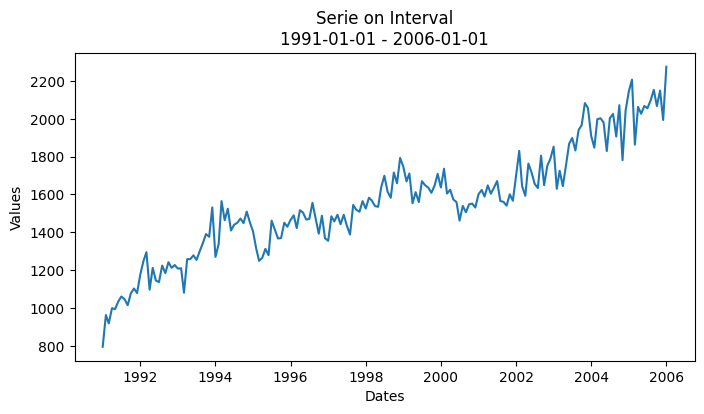

In [37]:
data_inicio_min, data_fim_min, data_inicio_max, data_fim_max  = '1985-01-01', '1999-01-01', '1985-01-01', '2010-01-01'
# data_inicio_min, data_fim_min, data_inicio_max, data_fim_max  = '2005-01-01', '2010-01-01', '2022-01-01', '2023-01-01'
a = df[(df.index > data_inicio_min) & (df.index < data_fim_min)].idxmin()
b = df[(df.index > data_inicio_max) & (df.index < data_fim_max)].idxmax()
print(a,b)

ts = df[(df.index >= a) & (df.index <= b)]
display(ts.head())
display(ts.tail())

fig = plt.figure(figsize=(8, 4))

plt.plot(ts)
plt.title(f'Serie on Interval\n{str(a)[0:10]} - {str(b)[0:10]}')
plt.xlabel('Dates')
plt.ylabel('Values')
plt.show()

In [38]:
train, test = ts.iloc[0:-5], ts.iloc[-5::]

display(train.tail())
display(test.head())

,HOUST
DATE,
2005-04-01,2062
2005-05-01,2026
2005-06-01,2067
2005-07-01,2055
2005-08-01,2096


,HOUST
DATE,
2005-09-01,2152
2005-10-01,2066
2005-11-01,2148
2005-12-01,1993
2006-01-01,2274


### Teste de estacionariedade (Dickey-Fuller Aumentado - ADF), **$d$**



In [39]:
def adf_test(series):
    result = adfuller(series)
    print('Teste ADF:')
    print(f'Estatística ADF: {result[0]}')
    print(f'Valor-p: {result[1]}')
    print('Valores Críticos:')
    for key, value in result[4].items():
        print(f'\t{key}: {value}')
    if result[1] <= 0.05:
        print('A série temporal é estacionária (rejeita H0)')
    else:
        print('A série temporal não é estacionária (falha em rejeitar H0)')
    return result[1]

adf_result = adf_test(train)

Teste ADF:
Estatística ADF: -1.2363107511000426
Valor-p: 0.6577840311867292
Valores Críticos:
	1%: -3.468952197801766
	5%: -2.878495056473015
	10%: -2.57580913601947
A série temporal não é estacionária (falha em rejeitar H0)


In [40]:
adf_test(train.diff().dropna())

Teste ADF:
Estatística ADF: -11.9016659967842
Valor-p: 5.556610985493593e-22
Valores Críticos:
	1%: -3.468952197801766
	5%: -2.878495056473015
	10%: -2.57580913601947
A série temporal é estacionária (rejeita H0)


np.float64(5.556610985493593e-22)

Teste ADF:
Estatística ADF: -11.9016659967842
Valor-p: 5.556610985493593e-22
Valores Críticos:
	1%: -3.468952197801766
	5%: -2.878495056473015
	10%: -2.57580913601947
A série temporal é estacionária (rejeita H0)


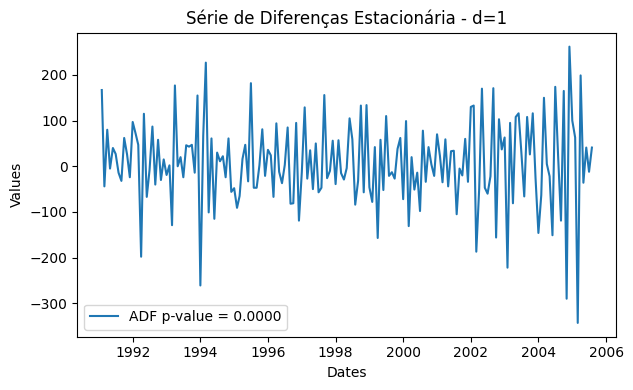

In [41]:
plt.figure(figsize=(12,4))

ts_diff = train.diff().dropna()
plt.subplot(1, 2, 1)
plt.plot(ts_diff, label = f'ADF p-value = {adf_test(ts_diff):.4f}')
plt.title('Série de Diferenças Estacionária - d=1')
plt.xlabel('Dates')
plt.ylabel('Values')
plt.legend()

plt.tight_layout()
plt.show()

### Auto-correlação e Correlação Parcial, ACF e PACF, **$q, p$**



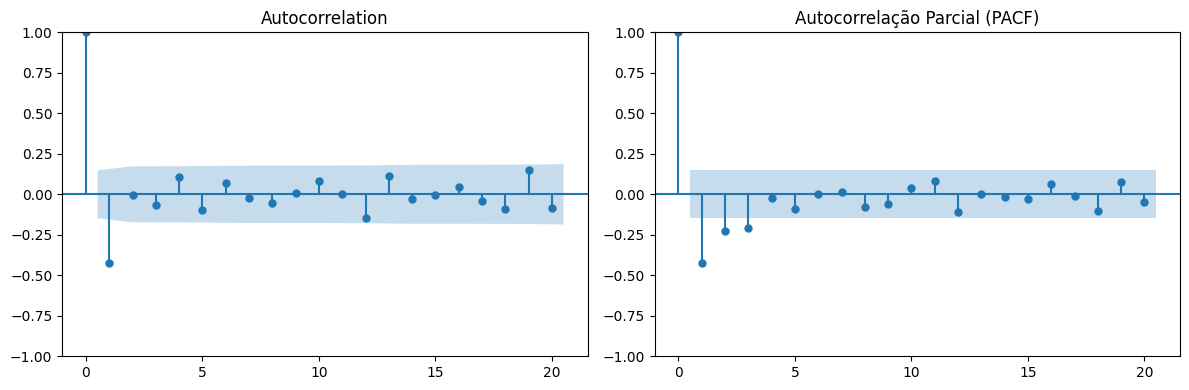

In [42]:
fig, [ax1, ax2] = plt.subplots(1,2,figsize=(12, 4))

plot_acf(ts_diff, lags=20, ax=ax1)
ax2.set_title('Autocorrelação (ACF)')

plot_pacf(ts_diff, lags=20, ax=ax2)
ax2.set_title('Autocorrelação Parcial (PACF)')

plt.tight_layout()
plt.show()



In [43]:
#@markdown #### Q4. Informe os valores obtidos dos parâmetros p, d, q de acordo com a sua análise.
#@markdown $p$ (termos do modelo AR) =
Q4A = 3 #@param {type:"number"}

#@markdown $d$ (diferenciação) =
Q4B = 1 #@param {type:"number"}

#@markdown $q$ (termos do modelo MA) =
Q4C = 1 #@param {type:"number"}

Q4['Q4A. p'] = Q4A
Q4['Q4B. d'] = Q4B
Q4['Q4C. q'] = Q4C

## Q5. ARIMA($p,d,q)$ e Forecast

Com base no modelo obtido construa um modelo ARIMA($p,d,q)$ fazendo a **PREDIÇÃO dos 5 últimos meses** da série do primeiro ciclo. Verifique o erro obtido (RMSE, raiz do erro médio quadrático) comparando os valores reais da série com os valores da sua predição.



                               SARIMAX Results                                
Dep. Variable:                  HOUST   No. Observations:                  176
Model:                 ARIMA(3, 1, 1)   Log Likelihood               -1018.556
Date:                Mon, 22 Jun 2026   AIC                           2047.113
Time:                        12:43:37   BIC                           2062.937
Sample:                    01-01-1991   HQIC                          2053.531
                         - 08-01-2005                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5291      0.384     -1.377      0.168      -1.282       0.224
ar.L2         -0.2991      0.193     -1.546      0.122      -0.678       0.080
ar.L3         -0.1881      0.089     -2.108      0.0

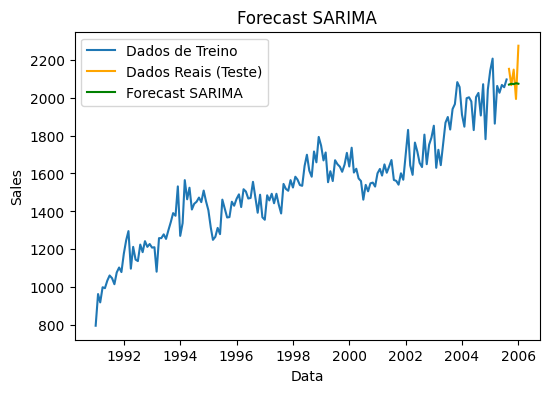

2005-09-01    2069.069675
2005-10-01    2073.312922
2005-11-01    2071.410900
2005-12-01    2076.213098
2006-01-01    2073.443158
Freq: MS, Name: predicted_mean, dtype: float64


In [58]:
order = (3,1,1)              # (p, d, q) não-sazonal
# seasonal_order = (0, 0, 0, 0) # (P, D, Q, s) sazonal

# Treinar o modelo SARIMA
# model = ARIMA(train, order=order, seasonal_order=seasonal_order)
model = ARIMA(train, order=order)
model_fit = model.fit()

print(model_fit.summary())

# Fazer o forecast
forecast_steps = len(test)

# forecast = model_fit.forecast(steps=forecast_steps) # Esta é a forma antiga
# Usar predict para um forecast mais robusto com índices
forecast = model_fit.predict(start=test.index[0], end=test.index[-1])

# Visualizar o forecast
plt.figure(figsize=(6,4))
plt.plot(train.index, train, label='Dados de Treino')
plt.plot(test.index, test, label='Dados Reais (Teste)', color='orange')
plt.plot(test.index, forecast, label='Forecast SARIMA', color='green')
plt.title('Forecast SARIMA')
plt.xlabel('Data')
plt.ylabel('Sales')
plt.legend()
plt.show()

print(forecast)


In [48]:
from sklearn.metrics import mean_squared_error
from math import sqrt
import numpy as np

# Calcular o RMSE para o conjunto de teste
rmse_test = sqrt(mean_squared_error(test, forecast))
print(f'RMSE do conjunto de teste: {rmse_test:.2f}')

# Calcular o MAPE para o conjunto de teste
mape_test = np.mean(np.abs(test - forecast) / test) * 100
print(f'MAPE do conjunto de teste: {mape_test:.2f} %')


RMSE do conjunto de teste: 109.49
MAPE do conjunto de teste: 4.15 %


In [49]:
#@markdown #### Q5. Informe os seguintes valores obtidos com seu modelo.
#@markdown Qual o coeficiente do 1o termo AR obtido:
Q5A = -0.5291 #@param {type:"number"}

#@markdown Qual o coeficiente do 1o termo MA obtido:
Q5B = -0.0271 #@param {type:"number"}

#@markdown Qual o AIC (Critério de Informação de Akaike) do modelo:
Q5C = 2047.113 #@param {type:"number"}

#@markdown Qual o último valor previsto da Série:
Q5D = 2073.443158 #@param {type:"number"}

#@markdown Qual RMSE da predição:
Q5E = 109.49 #@param {type:"number"}

Q5['Q5A. Coeficiente do 1o termo AR'] = Q5A
Q5['Q5B. Coeficiente do 1o termo MA'] = Q5B
Q5['Q5C. AIC'] = Q5C
Q5['Q5D. Último valor previsto'] = Q5D
Q5['Q5E. RMSE'] = Q5E


## Q6. Refinando o modelo ARIMA($p,d,q)$  

Analisando o modelo anterior observamos que há parâmetros não significativos. Verifique se o modelo, excluindo esses parâmetros, apresenta um resultado melhor que o anterior.

> **Nota**: No ARIMA, se o parâmetro de ordem $k$ é significativo, devem ser empregados todos os parâmetros de $1:k$. Isto é, os parâmetros anteriores, mesmo que não significativos devem ser considerados.



                               SARIMAX Results                                
Dep. Variable:                  HOUST   No. Observations:                  176
Model:                 ARIMA(3, 1, 0)   Log Likelihood               -1018.557
Date:                Mon, 22 Jun 2026   AIC                           2045.114
Time:                        12:21:30   BIC                           2057.773
Sample:                    01-01-1991   HQIC                          2050.249
                         - 08-01-2005                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5551      0.067     -8.316      0.000      -0.686      -0.424
ar.L2         -0.3124      0.066     -4.767      0.000      -0.441      -0.184
ar.L3         -0.1937      0.064     -3.029      0.0

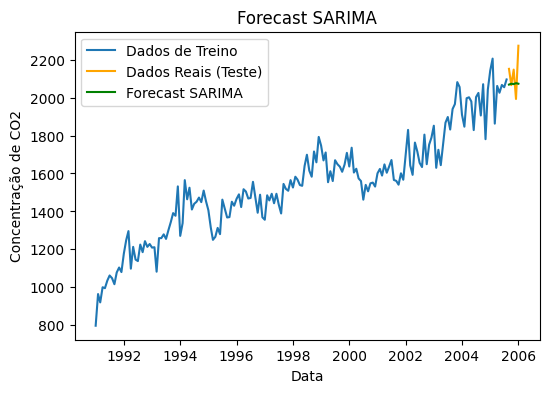

2005-09-01    2069.047634
2005-10-01    2073.524497
2005-11-01    2071.519515
2005-12-01    2076.453718
2006-01-01    2073.473891
Freq: MS, Name: predicted_mean, dtype: float64


In [50]:
order = (3,1,0)              # (p, d, q) não-sazonal
# seasonal_order = (0, 0, 0, 0) # (P, D, Q, s) sazonal

# Treinar o modelo SARIMA
# model = ARIMA(train, order=order, seasonal_order=seasonal_order)
model = ARIMA(train, order=order)
model_fit = model.fit()

print(model_fit.summary())

# Fazer o forecast
forecast_steps = len(test)

# forecast = model_fit.forecast(steps=forecast_steps) # Esta é a forma antiga
# Usar predict para um forecast mais robusto com índices
forecast = model_fit.predict(start=test.index[0], end=test.index[-1])

# Visualizar o forecast
plt.figure(figsize=(6,4))
plt.plot(train.index, train, label='Dados de Treino')
plt.plot(test.index, test, label='Dados Reais (Teste)', color='orange')
plt.plot(test.index, forecast, label='Forecast SARIMA', color='green')
plt.title('Forecast SARIMA')
plt.xlabel('Data')
plt.ylabel('Concentração de CO2')
plt.legend()
plt.show()

print(forecast)


In [51]:
# Calcular o RMSE para o conjunto de teste
rmse_test = sqrt(mean_squared_error(test, forecast))
print(f'RMSE do conjunto de teste: {rmse_test:.2f}')

# Calcular o MAPE para o conjunto de teste
mape_test = np.mean(np.abs(test - forecast) / test) * 100
print(f'MAPE do conjunto de teste: {mape_test:.2f} %')



RMSE do conjunto de teste: 109.51
MAPE do conjunto de teste: 4.16 %


In [52]:
#@markdown #### Q6. Informe os seguintes valores do novo modelo.
#@markdown Quais os novos parâmetros $(p,d,q)$ do novo modelo?
Q6A = "(3,1,0)" #@param {type:"string"}

#@markdown Qual o AIC (Critério de Informação de Akaike) do modelo:
Q6B = 2045.114 #@param {type:"number"}

#@markdown Qual o último valor previsto da Série:
Q6C = 2073.473891 #@param {type:"number"}

#@markdown Qual RMSE da predição:
Q6D = 109.51 #@param {type:"number"}

#@markdown Qual a sua conclusão, o novo modelo é melhor? (SIM | NÃO):
Q6E = 'Sim' #@param {type:"string"}

Q6['Q6A. Parâmetros do novo modelo'] = Q6A
Q6['Q6B. AIC'] = Q6B
Q6['Q6C. Último valor previsto'] = Q6C
Q6['Q6D. RMSE'] = Q6D


## Q7. Análise dos Resíduos

A rigor, a Análise dos Resíduos, antecede as predições. Mas aqui trata-se de um exercício. Verifique ao menos visualmente, a normalidade dos resíduos e se os resíduos encontram-se não auto-correlacionados (empregue o melhor modelo que obteve aqui).

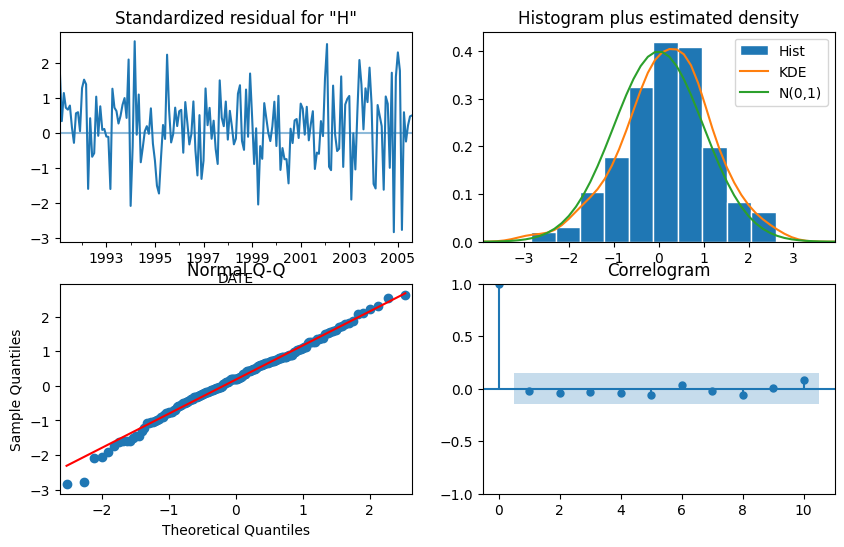

In [53]:
fig = model_fit.plot_diagnostics(figsize=(10, 6))
plt.show()

In [54]:
figname = 'P1_Q7_plot_' + Nome.replace(' ','_') + '_' + RA.replace('.','') + '.png'
fig.savefig(figname)

Q7['Q7A. Figura salva'] = figname
Q7['Q7B. Figura'] = fig

print(f'Figura salva em: {figname}')

Figura salva em: P1_Q7_plot_P2_gabarito_B_2201164-0.png


In [55]:
#@markdown #### Q7. Informe os resultados da sua análise.
#@markdown Os resíduos apresentam visualmente distribuição suficientemente normal? (SIM | NÃO):
Q7C = 'Sim' #@param {type:"string"}
#@markdown Os resíduos estão auto-correlacionados? (SIM | NÃO):
Q7D = 'Não' #@param {type:"string"}
#@markdown Este é portanto um modelo aparentemente adequado do ponto de vista dos resíduos? (SIM | NÃO):
Q7E = 'Sim' #@param {type:"string"}

Q7['Q7C. Distribuição Normal'] = Q7C
Q7['Q7D. Auto-correlação'] = Q7D
Q7['Q7E. Aptidão do modelo. Este é um bom modelo pela análise dos resíduos'] = Q7E
#

## Respostas Finais

In [56]:
#@markdown Execute para gerar e verificar suas respostas
import pickle
import numpy as np
import pandas as pd

# Define the filename with .pkl extension
filename = 'P1_' + Nome.replace(' ','_') + '_' + RA.replace('.','') + '.pkl'

# Serialize the dictionary to a pickle file
with open(filename, 'wb') as f:
      pickle.dump(example_dict, f)

from IPython.display import display, HTML

# display(HTML('<span style="font-family: Georgia; font-size: 24px; color: blue;">Respostas</span>'))
display(HTML('<span style="font-size: 24px; color: blue;">Respostas</span>'))
print()
for key, value in example_dict.items():
  if not isinstance(value, dict):
    print(f'{key}: {value}')
    print()
  else:
    print(f'{key}')
    for key2, value2 in value.items():
      print(f'{key2}: {value2}')
    print()
  print()

print()
display(HTML('<span style="font-size: 14px; color: blue;">Respostas salvas com sucesso em:</span>'))
print()
fname = f'<span style="font-size: 14px; color: blue;"><strong>{filename}</strong></span>'
display(HTML(fname))


Q1
Q1A1. Teste escolhido: chi2_contingency
Q1A2. p-value: 0.0
Q1B1. O embarque desacompanhado influência na sobrevivência dos passageiros?: Sim
Q1C1. P(sobrevivência|acompanhado): 0.505
Q1C2. P(sobrevivência|desacompanhado): 0.303
Q1C3. P_A/P_B: 1.67


Q2
Q2A1. Teste escolhido: ttest_ind(a, b, equal_var=False, alternative='less')
Q2A2. p-value: 0.02
Q2B1. Passageiros mais jovens estiveram associados a maiores taxas de sobrevivência?: Sim
Q2C1. Estatística escolhida: dCohen
Q2C2. Valor encontrado: 0.15
Q2C3. Influência: pequena


Q3
Q3. Figura salva: P1_Q4_plot_P2_gabarito_B_2201164-0.png
Q3. Figura: Figure(1200x400)


Q4
Q4A. p: 3
Q4B. d: 1
Q4C. q: 1


Q5
Q5A. Coeficiente do 1o termo AR: -0.5291
Q5B. Coeficiente do 1o termo MA: -0.0271
Q5C. AIC: 2047.113
Q5D. Último valor previsto: 2073.443158
Q5E. RMSE: 109.49


Q6
Q6A. Parâmetros do novo modelo: (3,1,0)
Q6B. AIC: 2045.114
Q6C. Último valor previsto: 2073.473891
Q6D. RMSE: 109.51


Q7
Q7A. Figura salva: P1_Q7_plot_P2_gabarito_B_22011

In [57]:
#@markdown Execute para fazer o download do arquivo com suas respostas
from google.colab import files
files.download(filename)


fname = f'<span style="font-size: 14px; color: blue;">Salve o arquivo {filename} para download.</strong></span>'
display(HTML(fname))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>